In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/arijitmohanta/02-preprocessing/__results__.html
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/X_feat.pkl
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/y.npy
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/X_img.npy
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/__output__.json
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/custom.css
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/__results___files/__results___4_0.png
/kaggle/input/notebooks/arijitmohanta/02-preprocessing/__results___files/__results___2_0.png
/kaggle/input/notebooks/arijitmohanta/04-modeling/classical_importances.pkl
/kaggle/input/notebooks/arijitmohanta/04-modeling/classical_predictions.pkl
/kaggle/input/notebooks/arijitmohanta/04-modeling/__results__.html
/kaggle/input/notebooks/arijitmohanta/04-modeling/cnn_predictions.pkl
/kaggle/input/notebooks/arijitmohanta/04-modeling/

In [1]:
# ============================================================
# STAGE 5.1 — LOCATE THE STAGE 4 + STAGE 2 ARTIFACTS ON KAGGLE
# Stage 5 reads SAVED predictions (no re-modeling) plus the raw images
# (to show the wafers behind each confusion). It needs:
#       - from 04-modeling  : classical_predictions.pkl, cnn_predictions.pkl,
#                             cnn_probabilities.npy, final_scores.pkl,
#       - from 02-preprocessing: X_img.npy (for visual confusion examples).
# Two inputs = two mount folders, each with its own slug, so we
#       1. Walk the input tree and print every file with its size,
#       2. Resolve the five files we need into full paths,
#       3. Surface any that are missing before Step 2 loads them.
# ============================================================

import os                                     # stdlib; all that's needed to walk the mounts

# Walk every folder under /kaggle/input and print each file with its size in MB.
# Expect two folders — 04-modeling (small prediction files) and 02-preprocessing
# (the large image tensor) — which visually confirms both inputs attached.
print("Full listing under /kaggle/input:\n")
for dirpath, dirnames, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        full = os.path.join(dirpath, f)
        print(f"{os.path.getsize(full) / 1e6:8.1f} MB   {full}")

# Resolve the five files Step 2 loads. Walking rather than hardcoding keeps this
# robust to Kaggle's slug-based mount paths, exactly as in Stages 2-4.
targets = ['classical_predictions.pkl', 'cnn_predictions.pkl',   # from 04-modeling
           'cnn_probabilities.npy', 'final_scores.pkl',          # from 04-modeling
           'X_img.npy']                                          # from 02-preprocessing
found = {}
for dirpath, dirnames, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        if f in targets:                                         # exact filename match only
            found[f] = os.path.join(dirpath, f)

print("\nTargets found:")
for t in targets:
    print(f"  {t:28s} {found.get(t, 'NOT FOUND')}")             # 'NOT FOUND' = missing/mis-attached

Full listing under /kaggle/input:

     0.0 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/classical_importances.pkl
     1.3 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/classical_predictions.pkl
     0.4 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/__results__.html
     0.8 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/cnn_predictions.pkl
     1.4 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/wafer_cnn.keras
     0.0 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/final_scores.pkl
     1.2 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/cnn_probabilities.npy
     0.0 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/classical_scores.pkl
     0.1 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/__notebook__.ipynb
     1.2 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/__output__.json
     0.0 MB   /kaggle/input/notebooks/arijitmohanta/04-modeling/custom.css
     0.4 MB   /kaggle/input/notebooks/arijitmohant

Truth labels agree across both prediction files: 34590 wafers


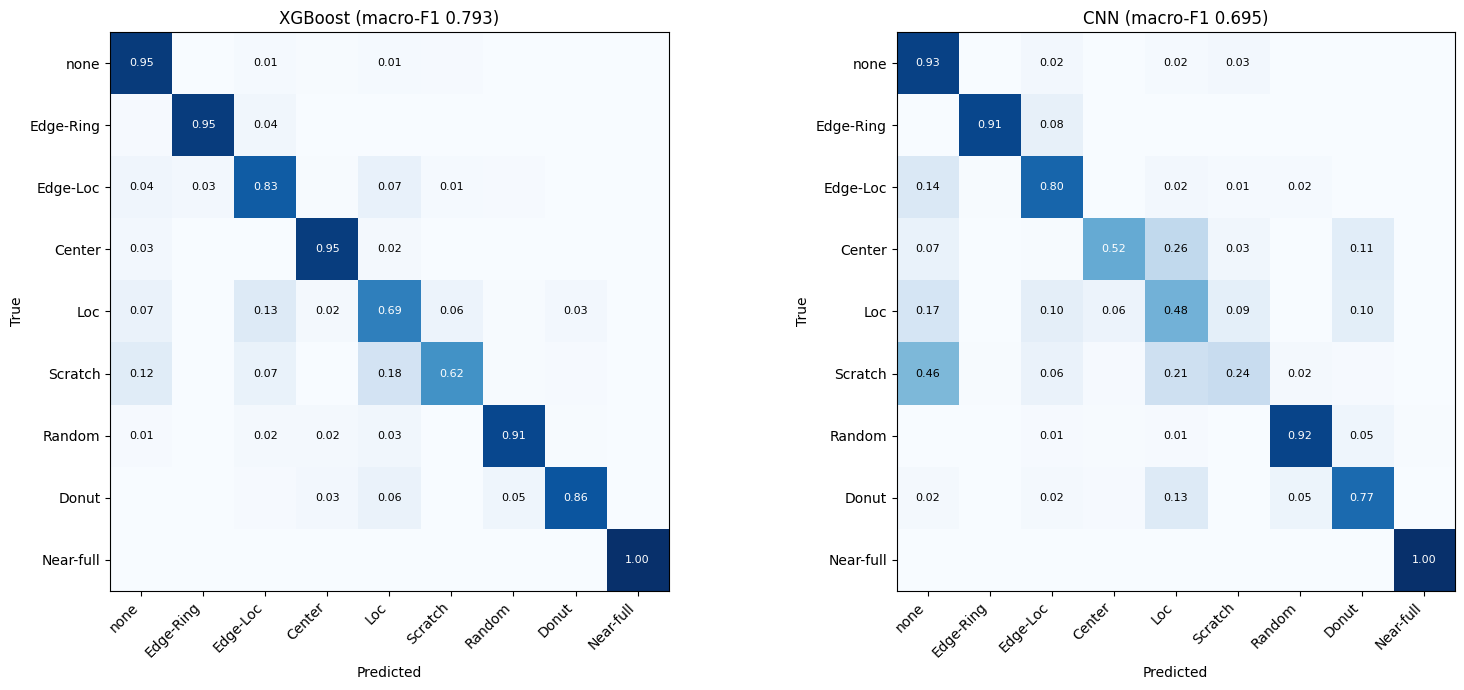


Row = true class, column = predicted. Diagonal = recall; bright off-diagonals = confusions.


In [2]:
# ============================================================
# STAGE 5.2 — LOAD PREDICTIONS + BUILD CONFUSION MATRICES
# Read the frozen Stage 4 predictions (no re-modelling) and turn them
# into the two confusion matrices the rest of the stage interprets.
#       1. load classical + CNN prediction tables, assert their truth
#          columns agree (same test wafers, same order),
#       2. build confusion matrices for XGBoost (best classical) and CNN,
#       3. plot them side by side, ROW-NORMALISED (each row = recall
#          breakdown for one true class), in fixed class order.
# CPU only — this is reading and plotting, no model runs.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Resolve the two mount folders from Step 1.
P4 = '/kaggle/input/notebooks/arijitmohanta/04-modeling'
P2 = '/kaggle/input/notebooks/arijitmohanta/02-preprocessing'

# Load the saved predictions. Both tables are indexed by the same test_idx and
# carry a 'y_true' column; the classical file adds rf/xgb/svm columns, the CNN
# file a 'cnn' column.
clf = pd.read_pickle(f'{P4}/classical_predictions.pkl')   # y_true, rf, xgb, svm
cnn = pd.read_pickle(f'{P4}/cnn_predictions.pkl')          # y_true, cnn

# INTEGRITY CHECK — the two files were produced in different sessions (the CNN
# after a kernel restart), so before trusting a joint comparison, we assert their
# truth columns are identical row-for-row. If they disagree, the wafers don't line
# up and every confusion below would be garbage.
assert (clf['y_true'].values == cnn['y_true'].values).all(), "Truth labels differ between files!"
y_true = clf['y_true'].values
print("Truth labels agree across both prediction files:", len(y_true), "wafers")

# Fixed class order (frequency-descending, matching every prior report) so both
# matrices share axes and read the same way.
class_order = pd.Series(y_true).value_counts().index.tolist()

# Build both confusion matrices on the shared label order. normalize='true' makes
# each ROW sum to 1.0 -> the diagonal is per-class recall, off-diagonals are where
# that class's true members were missent. This is the imbalance-proof reading.
cm_xgb = confusion_matrix(y_true, clf['xgb'].values, labels=class_order, normalize='true')
cm_cnn = confusion_matrix(y_true, cnn['cnn'].values, labels=class_order, normalize='true')

# Plot side by side with a shared colour scale, annotating each cell with its
# fraction so the numbers are readable, not just the shading.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, title in [(axes[0], cm_xgb, 'XGBoost (macro-F1 0.793)'),
                      (axes[1], cm_cnn, 'CNN (macro-F1 0.695)')]:
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)          # shared 0-1 scale for fair comparison
    ax.set_xticks(range(len(class_order))); ax.set_yticks(range(len(class_order)))
    ax.set_xticklabels(class_order, rotation=45, ha='right'); ax.set_yticklabels(class_order)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(len(class_order)):                        # annotate every cell with its fraction
        for j in range(len(class_order)):
            v = cm[i, j]
            if v >= 0.01:                                    # skip near-zero cells to reduce clutter
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v > 0.5 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

print("\nRow = true class, column = predicted. Diagonal = recall; bright off-diagonals = confusions.")

In [3]:
# ============================================================
# STAGE 5.3 — RANK THE HOT CONFUSIONS (both models, raw counts)
# Turn the two confusion matrices into a targeted, quantified list so
# the root-cause writeup cites real numbers, not eyeballed shading.
#       1. rebuild both matrices as RAW COUNTS (not normalised),
#       2. extract every off-diagonal cell, tag it true->pred + fraction
#          of that true class, for each model,
#       3. rank by count and print the top confusions per model,
#       4. flag the confusions the TWO models SHARE vs the ones unique
#          to each — shared = intrinsically hard, unique = representational.
# ============================================================

from sklearn.metrics import confusion_matrix

# Raw-count matrices (no normalisation) so we recover actual wafer numbers. Row
# fractions are computed alongside for context (how big a leak is, relative to
# that true class's size).
cm_xgb_n = confusion_matrix(y_true, clf['xgb'].values, labels=class_order)
cm_cnn_n = confusion_matrix(y_true, cnn['cnn'].values, labels=class_order)
row_totals = cm_xgb_n.sum(axis=1)                          # true-class sizes (same for both models)

# Walk every off-diagonal cell of a matrix and collect (true, pred, count, frac).
# frac = count / size of the true class = the share of that class misrouted here.
def confusions(cm, min_count=20):                          # ignore tiny cells (<20 wafers) as noise
    rows = []
    for i, t in enumerate(class_order):
        for j, p in enumerate(class_order):
            if i != j and cm[i, j] >= min_count:           # off-diagonal, above the noise floor
                rows.append({'true': t, 'pred': p,
                             'count': int(cm[i, j]),
                             'frac_of_true': cm[i, j] / row_totals[i]})
    return pd.DataFrame(rows).sort_values('count', ascending=False).reset_index(drop=True)

conf_xgb = confusions(cm_xgb_n)
conf_cnn = confusions(cm_cnn_n)

# Top confusions per model, formatted as "True -> Pred : N wafers (X% of true class)".
def show(df, title, k=8):
    print(f"\n{title} — top {k} confusions:")
    for _, r in df.head(k).iterrows():
        print(f"  {r['true']:>9} -> {r['pred']:<9} {r['count']:5d} wafers "
              f"({r['frac_of_true']*100:4.1f}% of all {r['true']})")

show(conf_xgb, "XGBoost (macro-F1 0.793)")
show(conf_cnn, "CNN (macro-F1 0.695)")

# Which confusions do BOTH models make? A shared confusion (same true->pred pair
# in both top lists) points to classes that intrinsically resemble each other —
# a FEATURE/physics limit no model escapes. A confusion unique to one model is a
# REPRESENTATION artifact of that model. This split is the spine of the writeup.
pairs_xgb = set(zip(conf_xgb['true'], conf_xgb['pred']))
pairs_cnn = set(zip(conf_cnn['true'], conf_cnn['pred']))
shared = pairs_xgb & pairs_cnn
print("\n\nSHARED confusions (both models — intrinsically hard / feature-limited):")
for t, p in sorted(shared, key=lambda x: -cm_xgb_n[class_order.index(x[0]), class_order.index(x[1])]):
    print(f"  {t} -> {p}")
print("\nUNIQUE to CNN (representational — CNN sees pixels, misses engineered geometry):")
for t, p in sorted(pairs_cnn - pairs_xgb):
    print(f"  {t} -> {p}")


XGBoost (macro-F1 0.793) — top 8 confusions:
       none -> Edge-Loc    441 wafers ( 1.5% of all none)
       none -> Loc         370 wafers ( 1.3% of all none)
       none -> Scratch     292 wafers ( 1.0% of all none)
       none -> Center      179 wafers ( 0.6% of all none)
        Loc -> Edge-Loc     93 wafers (13.0% of all Loc)
       none -> Edge-Ring    76 wafers ( 0.3% of all none)
   Edge-Loc -> Loc          75 wafers ( 7.2% of all Edge-Loc)
  Edge-Ring -> Edge-Loc     68 wafers ( 3.5% of all Edge-Ring)

CNN (macro-F1 0.695) — top 8 confusions:
       none -> Scratch     789 wafers ( 2.7% of all none)
       none -> Edge-Loc    724 wafers ( 2.5% of all none)
       none -> Loc         446 wafers ( 1.5% of all none)
     Center -> Loc         227 wafers (26.4% of all Center)
  Edge-Ring -> Edge-Loc    158 wafers ( 8.2% of all Edge-Ring)
   Edge-Loc -> none        146 wafers (14.1% of all Edge-Loc)
        Loc -> none        123 wafers (17.1% of all Loc)
    Scratch -> none     

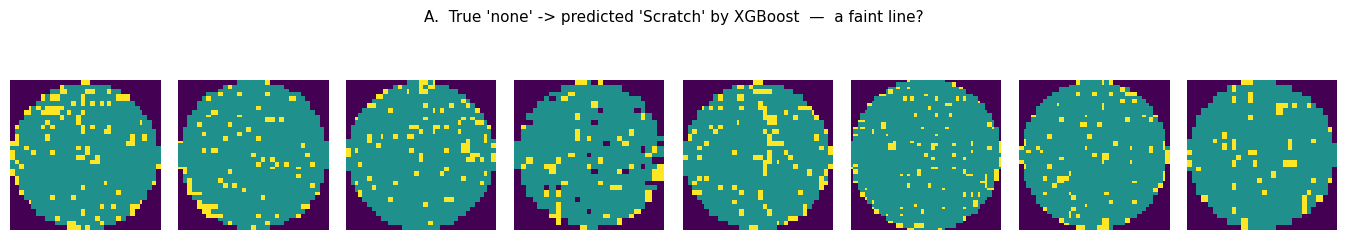

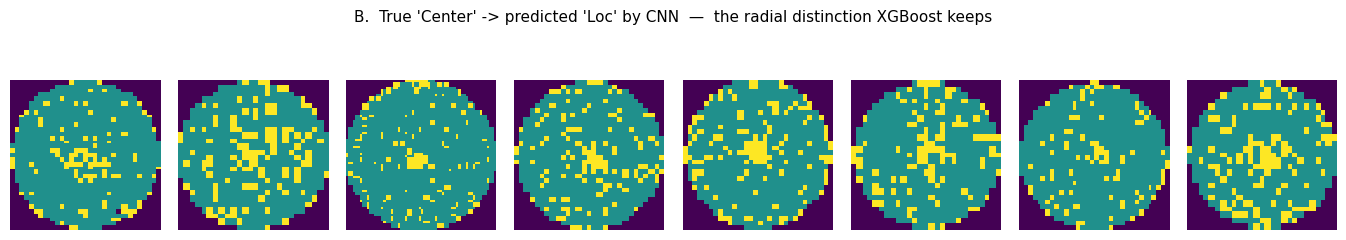

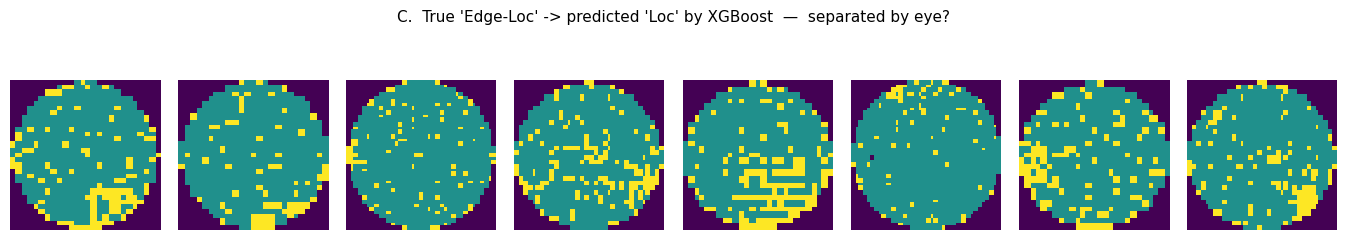

Failing dies = brightest level. Row = wafer maps for one confusion type.


In [5]:
# ============================================================
# STAGE 5.4 — VISUAL CONFUSION GALLERIES (the maps behind the errors)
# Pull the real wafer maps for three diagnostic confusions and plot
# them, each block captioned for the claim it tests:
#       A. none -> Scratch  : label-noise test — do these "none" wafers
#                             actually show a faint line?
#       B. Center -> Donut/Loc (CNN) : the radial collapse XGBoost avoids
#       C. Edge-Loc <-> Loc : intrinsic geometric ambiguity (should be
#                             genuinely hard to separate by eye too)
# Images are fetched from X_img by the ORIGINAL row index the prediction
# tables carry (test_idx), so no re-slicing or misalignment is possible.
# CPU only — indexing and plotting.
# ============================================================

# Load the full image tensor once (read-only, from Stage 2). We index it by the
# original-row positions stored in the prediction table's index, so image and
# prediction always refer to the same physical wafer.
X_img = np.load(f'{P2}/X_img.npy')                         # (172950, 64, 64) uint8

# Helper: given a model's prediction column, return the ORIGINAL row indices of up
# to n wafers whose TRUE class is `true_cls` but were predicted `pred_cls`. The
# table index IS the original position, so we return it directly for X_img lookup.
def confusion_examples(pred_col, true_cls, pred_cls, n=8, source=clf):
    mask = (source['y_true'] == true_cls) & (source[pred_col] == pred_cls)
    return source.index[mask][:n].tolist()               # original X_img row positions

# Generic gallery renderer: one row of wafer maps for a given confusion, titled.
# cmap is 3-level (0=outside, 1=pass, 2=fail) shown as distinct greys/colour so the
# failing dies — the actual signal — stand out from pass dies and background.
def gallery(indices, title, ncols=8):
    n = len(indices)
    if n == 0:
        print(f"(no examples found for: {title})"); return
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 1.7, 2.1))
    fig.suptitle(title, fontsize=11, y=1.12, ha='center')
    for k in range(ncols):
        ax = axes[k]; ax.axis('off')
        if k < n:
            # imshow with 3 discrete levels: 'viridis' maps 0/1/2 to distinct colours
            # so failing dies (2) read as bright against pass (1) and outside (0).
            ax.imshow(X_img[indices[k]], cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    plt.tight_layout(); plt.show()

# --- GALLERY A: none -> Scratch (label-noise test) ---
# If these "none" wafers show a visible faint diagonal/linear streak of failing
# dies, the label (not the model) is the error — two models agreeing on structure
# the annotator missed. This is the panel that tests the Stage 1 label-noise flag.
a_xgb = confusion_examples('xgb', 'none', 'Scratch', n=8, source=clf)
gallery(a_xgb, "A.  True 'none' -> predicted 'Scratch' by XGBoost  —  a faint line?")

# --- GALLERY B: Center -> Loc/Donut, CNN only (radial collapse) ---
# The CNN loses the center-vs-annulus distinction the radial feature hands XGBoost.
# Pulled from the CNN table. Caption pairs the claim: these are radial patterns the
# CNN misrouted into other radial classes.
b_cnn = confusion_examples('cnn', 'Center', 'Loc', n=8, source=cnn)
gallery(b_cnn, "B.  True 'Center' -> predicted 'Loc' by CNN  —  the radial distinction XGBoost keeps")

# --- GALLERY C: Edge-Loc <-> Loc (intrinsic ambiguity) ---
# Shown from XGBoost. If these are hard to tell apart by eye, the confusion is real
# geometry (does the cluster touch the edge?), not model weakness — an honest panel.
c_xgb = confusion_examples('xgb', 'Edge-Loc', 'Loc', n=8, source=clf)
gallery(c_xgb, "C.  True 'Edge-Loc' -> predicted 'Loc' by XGBoost  —  separated by eye?")

print("Failing dies = brightest level. Row = wafer maps for one confusion type.")

Cost-weighted scorecard (relative units; miss=10, misroute=3, false_alarm=1):

                      miss  false_alarm  misroute  total  pct_loss_avoided
model                                                                     
do_nothing_baseline  51040            0         0  51040               0.0
xgboost               1580         1369      1488   4437              91.3
cnn                   4450         2032      2847   9329              81.7


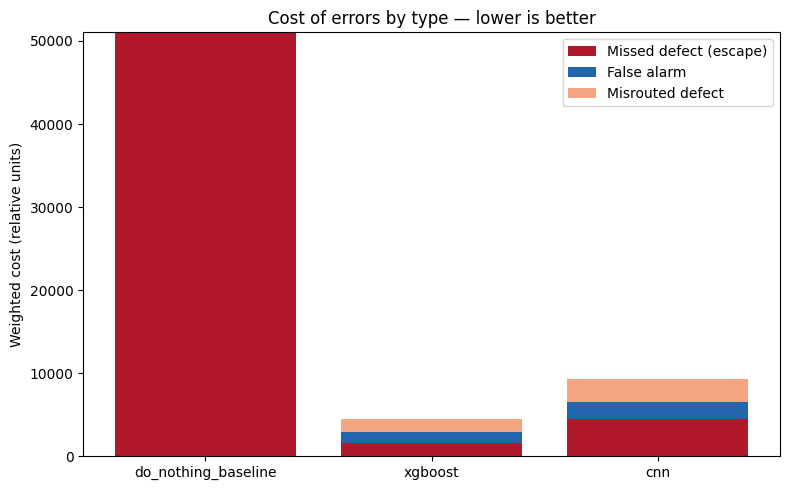

In [6]:
# ============================================================
# STAGE 5.5 — YIELD-ECONOMICS LAYER (cost-weighted confusion)
# A plain confusion matrix treats every error equally; a fab does not.
# We weight each error by the COST OF ITS TYPE and compare models in
# fab-relevant terms:
#       1. Define relative costs (editable — plug in a real fab's numbers),
#       2. Build a 9x9 cost matrix from the error taxonomy,
#       3. Weight each model's raw-count confusion matrix by it, split
#          into miss / false-alarm / misroute components,
#       4. Compare against a do-nothing baseline (predict-all-'none'),
#          reporting each model's total cost and % of potential loss avoided.
# Costs are RELATIVE and illustrative; the qualitative ranking is robust
# as long as a missed defect costs more than a false alarm.
# ============================================================

# (1) Relative error costs. These are illustrative units, not dollars — the point
# is the ratio, and a reviewer can substitute their fab's real cost-of-escape,
# review-hour, and misrouted-investigation figures. Miss >> misroute > false alarm
# reflects that a defect ESCAPING is the yield-critical failure mode.
C_MISS        = 10   # true defect -> 'none' : defect escapes the net (worst)
C_MISROUTE    = 3    # defect A -> defect B  : caught, but wrong root-cause label
C_FALSE_ALARM = 1    # 'none' -> defect      : wasted review (likely overstated — see Step 4)

# (2) Build the 9x9 cost matrix by walking the taxonomy. 'none' is the only
# non-defect class; everything else is a defect. Correct cells (diagonal) cost 0.
defects = [c for c in class_order if c != 'none']
cost_matrix = np.zeros((len(class_order), len(class_order)))
for i, t in enumerate(class_order):
    for j, p in enumerate(class_order):
        if i == j:                              continue          # correct -> 0
        elif t == 'none' and p in defects:      cost_matrix[i, j] = C_FALSE_ALARM   # false alarm
        elif t in defects and p == 'none':      cost_matrix[i, j] = C_MISS          # MISS (escape)
        elif t in defects and p in defects:     cost_matrix[i, j] = C_MISROUTE      # misrouted

# (3) Weight each model's raw-count confusion by the cost matrix, then split the
# total into the three components so we can see WHERE each model's cost sits, not
# just the sum. A model can have the same total for very different reasons.
def cost_breakdown(y_pred_col):
    cm = confusion_matrix(y_true, y_pred_col, labels=class_order)   # raw counts
    weighted = cm * cost_matrix                                     # cost per cell
    # Masks over the (true, pred) grid to sum each error type separately.
    miss  = sum(cm[i, class_order.index('none')] * C_MISS
                for i, t in enumerate(class_order) if t in defects)
    false = sum(cm[class_order.index('none'), j] * C_FALSE_ALARM
                for j, p in enumerate(class_order) if p in defects)
    route = weighted.sum() - miss - false                          # remainder = misroutes
    return {'miss': miss, 'false_alarm': false, 'misroute': route, 'total': weighted.sum()}

xgb_cost = cost_breakdown(clf['xgb'].values)
cnn_cost = cost_breakdown(cnn['cnn'].values)

# (4) Do-nothing baseline: predict 'none' for every wafer -> every true defect is
# missed, zero false alarms. This is the loss a fab with NO triage model absorbs,
# and the yardstick for "what is the model worth?".
n_defect_true = sum(1 for t in y_true if t in defects)            # test wafers that are truly defects
baseline_cost = n_defect_true * C_MISS

# Assemble the business scorecard: cost components + total + % of the do-nothing
# loss each model avoids (value delivered, in fab terms).
rows = []
for name, c in [('do_nothing_baseline', {'miss': baseline_cost, 'false_alarm': 0, 'misroute': 0, 'total': baseline_cost}),
                ('xgboost', xgb_cost), ('cnn', cnn_cost)]:
    rows.append({'model': name, **{k: int(round(v)) for k, v in c.items()},
                 'pct_loss_avoided': round(100 * (1 - c['total'] / baseline_cost), 1)})
scorecard = pd.DataFrame(rows).set_index('model')
print("Cost-weighted scorecard (relative units; miss=10, misroute=3, false_alarm=1):\n")
print(scorecard)

# Stacked bar: how each model converts the tall do-nothing MISS bar into a short,
# mostly-cheap mix. The visual is the business-impact figure for the README.
fig, ax = plt.subplots(figsize=(8, 5))
labels = scorecard.index.tolist()
ax.bar(labels, scorecard['miss'],        label='Missed defect (escape)',  color='#b2182b')
ax.bar(labels, scorecard['false_alarm'], bottom=scorecard['miss'], label='False alarm', color='#2166ac')
ax.bar(labels, scorecard['misroute'],    bottom=scorecard['miss'] + scorecard['false_alarm'],
       label='Misrouted defect', color='#f4a582')
ax.set_ylabel('Weighted cost (relative units)'); ax.set_title('Cost of errors by type — lower is better')
ax.legend()
plt.tight_layout(); plt.show()

In [7]:
# ============================================================
# STAGE 5.6 — EXPORT ALL STAGE 5 FIGURES
# The analysis figures were shown but not saved. This cell re-renders
# each from the in-memory results and writes README-ready PNGs:
#       1. The two confusion matrices (side by side),
#       2. The three confusion galleries (none->Scratch, Center->Loc,
#          Edge-Loc->Loc),
#       3. the cost-by-error-type bar chart.
# Files land in /kaggle/working/images/ with stage-5_ .
# CPU only.
# ============================================================

import os

# Make the output image folder (no error if it already exists). Everything saves
# here so the Save Version snapshot carries a tidy images/ directory to GitHub.
os.makedirs('/kaggle/working/images', exist_ok=True)
IMG = '/kaggle/working/images'

# --- 1. Confusion matrices (re-render the Step 2 row-normalised pair, then save) ---
# Rebuilt from the in-memory cm_xgb / cm_cnn so the saved figure is identical to
# what you reviewed. savefig with bbox_inches='tight' trims whitespace; dpi=150
# keeps it crisp in the README without being huge.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, title in [(axes[0], cm_xgb, 'XGBoost (macro-F1 0.793)'),
                      (axes[1], cm_cnn, 'CNN (macro-F1 0.695)')]:
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(class_order))); ax.set_yticks(range(len(class_order)))
    ax.set_xticklabels(class_order, rotation=45, ha='right'); ax.set_yticklabels(class_order)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(len(class_order)):
        for j in range(len(class_order)):
            v = cm[i, j]
            if v >= 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v > 0.5 else 'black', fontsize=8)
plt.tight_layout()
fig.savefig(f'{IMG}/stage-5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.close(fig)                                   # free the figure; we're saving, not displaying

# --- 2. The three galleries (save-capable version of the Step 4 renderer) ---
# Same layout as Step 4, but returns/saves the figure instead of calling show().
# Reuses the index lists already computed in Step 4 (a_xgb, b_cnn, c_xgb).
def save_gallery(indices, title, fname, ncols=8):
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 1.7, 2.1))
    fig.suptitle(title, fontsize=11, y=1.12, ha='center')
    for k in range(ncols):
        ax = axes[k]; ax.axis('off')
        if k < len(indices):
            ax.imshow(X_img[indices[k]], cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    plt.tight_layout()
    fig.savefig(f'{IMG}/{fname}', dpi=150, bbox_inches='tight')
    plt.close(fig)

save_gallery(a_xgb, "True 'none' -> predicted 'Scratch' (XGBoost): partial label noise",
             'stage-5_gallery_none_scratch.png')
save_gallery(b_cnn, "True 'Center' -> predicted 'Loc' (CNN): radial distinction lost",
             'stage-5_gallery_center_loc.png')
save_gallery(c_xgb, "True 'Edge-Loc' -> predicted 'Loc' (XGBoost): intrinsic ambiguity",
             'stage-5_gallery_edgeloc_loc.png')

# --- 3. Cost-by-error-type chart (re-render the Step 5 stacked bar, then save) ---
# Rebuilt from the in-memory scorecard so the business figure matches the numbers
# you reviewed (do-nothing 51,040 -> XGBoost 4,437 -> CNN 9,329).
fig, ax = plt.subplots(figsize=(8, 5))
labels = scorecard.index.tolist()
ax.bar(labels, scorecard['miss'],        label='Missed defect (escape)', color='#b2182b')
ax.bar(labels, scorecard['false_alarm'], bottom=scorecard['miss'], label='False alarm', color='#2166ac')
ax.bar(labels, scorecard['misroute'],    bottom=scorecard['miss'] + scorecard['false_alarm'],
       label='Misrouted defect', color='#f4a582')
ax.set_ylabel('Weighted cost (relative units)'); ax.set_title('Cost of errors by type — lower is better')
ax.legend()
plt.tight_layout()
fig.savefig(f'{IMG}/stage-5_cost_by_error_type.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Confirm every figure wrote, with size, before committing ---
print("Saved figures in /kaggle/working/images/:\n")
for f in sorted(os.listdir(IMG)):
    if f.startswith('stage-5'):
        kb = os.path.getsize(f'{IMG}/{f}') / 1024
        print(f"  {f:44s} {kb:7.1f} KB")

Saved figures in /kaggle/working/images/:

  stage-5_confusion_matrices.png                 119.8 KB
  stage-5_cost_by_error_type.png                  47.6 KB
  stage-5_gallery_center_loc.png                  19.8 KB
  stage-5_gallery_edgeloc_loc.png                 21.0 KB
  stage-5_gallery_none_scratch.png                20.3 KB
